<a href="https://colab.research.google.com/github/yaelmagen/fraud-detection/blob/main/Nuvei_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Multilayered Fraud Detection System

**Overview:**

I developed a robust, production-ready fraud detection engine designed to identify sophisticated payment anomalies within a user cohort dataset. The system transitions from raw data ingestion to a tiered decision-making framework, balancing statistical machine learning with deterministic business logic

**Methodology & Feature Engineering:**

- Behavioral Profiling: Engineered high-impact features including amount_to_avg_ratio (detecting spikes up to 204x) and Same-Amount Velocity to capture automated bot bursts.
- Geographic Risk: Developed cross-region "Impossible Travel" and "Suspicious Velocity" indicators to monitor account integrity across 134 countries.
- Data Integrity: Identified and isolated "Broken Records" (missing device/payment metadata), treating them as high-risk behavioral indicators.


**Hybrid Detection Engine:**

Recognizing that no single algorithm is a silver bullet, I implemented a Dual-Lens Ensemble:
- **Isolation Forest (Global Outliers):** Effectively captured high-magnitude anomalies, such as extreme transaction amounts and seniority-based risks.
- **Local Outlier Factor (Local Context):** Successfully identified 75 unique "silent" anomalies (e.g., high-value transactions in rare regions) that were overlooked by global modeling.
- **Deterministic Rules Layer:** Implemented "Hard Flags" for immediate blocking of high-confidence violations (Geographic Impossibility), ensuring 100% coverage for clear logical risks.

**Data Insights & Scalability**

Analysis of the transaction volume and PCA diagnostics revealed a natural Cohort Aging process (shifting from 50% new users in June to <1% in the test set). To maintain long-term accuracy, I proposed a Rolling Window Retraining Strategy. This ensures the model remains resilient to data drift and consistently recognizes legitimate new user behavior as the platform scales.


**Limitations & aspects to consider:**
  - cold start problem
  - dataset includes only the first four months of user activity following onboarding which limits the ability to capture long-term behavioral patterns and seasonal effects

I addressed the Cold Start problem using a three-tiered approach:

**Mathematical Imputation:** Assigned neutral values to history-based features (a 1.0 ratio and 'infinite' time-delta) to prevent false positives during a user's first transaction.

**Contextual Encoding:** Provided the model with seniority and is_new_user flags, allowing it to differentiate between a legitimate lack of history and a suspicious deviation in behavior.

**Non-Historical Rules:** Leveraged deterministic indicators like Geographic Impossibility and Metadata Integrity (Broken Records), which provide immediate protection even when user profiling data is unavailable.

**Conclusion:**

The final system categorizes transactions into a tiered risk structure (Critical, High, Medium, Low), allowing for automated blocking of blatant fraud while optimizing manual review resources. This approach maximizes security coverage without compromising the user experience for legitimate global traffic.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
file_name = 'DS_Test_Dataset.xlsx'

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
file_path = "gdrive/MyDrive/Nuvei"

In [5]:
raw_data = pd.read_excel(os.path.join(file_path, file_name))

In [6]:
raw_data.head()

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type
0,66675334,11008761,210,2024-05-31 23:56:04.000,2024-05-31 23:56:04.000,109.86,credit_card,CAD,7.045880,1,109.86,CA,NaN,pc
1,66675371,11008762,117,2024-06-01 00:00:02.000,2024-06-01 00:00:02.149,108.71,credit_card,USD,3.236956,1,108.71,US,DC,mobile
2,66675434,11008768,248,2024-06-01 00:07:45.586,2024-06-01 00:07:45.586,150.00,credit_card,USD,3.431595,1,150.00,US,MO,mobile
3,66675492,11008775,288,2024-06-01 00:12:08.248,2024-06-01 00:12:08.248,30.00,credit_card,USD,1.600267,1,30.00,US,TX,mobile
4,66675558,11008784,160,2024-06-01 00:18:10.409,2024-06-01 00:18:10.409,41.42,credit_card,EUR,2.335492,1,41.42,FR,NaN,mobile


In [7]:
print("first registration date:", raw_data.first_approved_payment_timestamp.min())
print("last registration date:", raw_data.first_approved_payment_timestamp.max())

first registration date: 2024-05-31 23:56:04
last registration date: 2024-06-30 23:54:03.575000


In [8]:
print("first approved payment date:", raw_data.payment_timestamp.min())
print("last approved payment date:", raw_data.payment_timestamp.max())

first approved payment date: 2024-05-31 23:56:04
last approved payment date: 2024-10-28 11:47:18.139000


# EDA & Feature Engineering

Goals:

- General view
- Cleaning and handle missing values
- Features analysis
- Time aspect
- Adding indicators and new features

## General view and Sanity checks

In [9]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41321 entries, 0 to 41320
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   payment_id                          41321 non-null  int64         
 1   user_id                             41321 non-null  int64         
 2   merchant_id                         41321 non-null  int64         
 3   payment_timestamp                   41321 non-null  datetime64[ns]
 4   first_approved_payment_timestamp    41321 non-null  datetime64[ns]
 5   total_amount_usd                    41321 non-null  float64       
 6   payment_instrument                  41309 non-null  object        
 7   currency                            41321 non-null  object        
 8   time_to_complete_payment            41321 non-null  float64       
 9   num_approved_payments_per_user      41321 non-null  int64         
 10  total_approved_amount_

In [10]:
#convert object columns to category
obj_cols = raw_data.select_dtypes(include='object').columns
raw_data[obj_cols] = raw_data[obj_cols].astype("category")


In [11]:
categorical = [col for col in obj_cols]
categorical.append('merchant_id')

Check for duplications

In [12]:
#check that payment_id is globally unique
print("Duplicate payment_id:", raw_data['payment_id'].duplicated().sum())

Duplicate payment_id: 0


In [13]:
#check number of unique users
print("number of unique users", raw_data.user_id.nunique())

number of unique users 16208


In [14]:
#check if user_id maps to one country
raw_data.groupby('user_id')['country'].nunique().max() == 1

False

In [15]:
sum(raw_data.groupby('user_id')['state'].nunique()!=1)

12620

In [16]:
sum(raw_data.groupby('user_id')['country'].nunique()!=1)

42

I identified 42 users active in multiple countries. While this can indicate legitimate travel or VPN usage, I flagged payments exhibiting 'Impossible Travel' patterns - where transactions occurred in different geographic locations within a timeframe that precludes physical travel. This is a strong indicator of potential Account Takeover (ATO) or credential sharing.

In [17]:
def get_region(country):
    central_west_europe = [
        'GB', 'DE', 'FR', 'IT', 'ES', 'NL', 'NO', 'PT', 'CH', 'AT', 'SE', 'DK', 'FI',
        'BE', 'IE', 'GR', 'LU', 'IS', 'MT', 'AD', 'MC', 'GL', 'AX', 'FO', 'GG', 'JE', 'LI',
        'PL', 'CZ', 'SK', 'HU', 'SI'
    ]

    east_europe_balkans = [
        'RO', 'UA', 'MD', 'EE', 'LT', 'LV', 'RS', 'MK', 'BA', 'AL', 'ME'
    ]

    me_caucasus = ['IL', 'CY', 'AM', 'GE', 'KZ', 'AZ', 'TR']

    if country in central_west_europe: return 'Central_West_Europe'
    if country in east_europe_balkans: return 'East_Europe_Balkans'
    if country in me_caucasus: return 'ME_Caucasus'

    if country in ['US', 'CA', 'MX', 'PR', 'AG', 'AW', 'BB', 'BM', 'BQ', 'BS', 'CW', 'DM', 'DO', 'GD', 'GP', 'GU', 'LC', 'MF', 'MQ', 'TC', 'VG', 'VI']: return 'North_America'
    if country in ['BR', 'CL', 'CO', 'PE', 'AR', 'UY', 'EC', 'GT', 'HN', 'CR', 'PY', 'SV', 'NI', 'GF', 'GY']: return 'South_Latam_America'
    if country in ['SG', 'JP', 'AE', 'IN', 'TW', 'MY', 'HK', 'BH', 'KW', 'QA', 'KH', 'ID', 'LA', 'KR', 'UZ', 'TH', 'NP', 'MN', 'TJ', 'LK', 'PK', 'OM', 'NC', 'PF', 'TO', 'TV']: return 'Asia_Oceania'
    if country in ['CI', 'MA', 'MU', 'BJ', 'GH', 'ET', 'BW', 'AO', 'RW', 'CG', 'LR', 'DZ', 'EG', 'MG', 'TN', 'TG', 'GQ', 'RE', 'SC']: return 'Africa'
    if country in ['AU', 'NZ', 'CK']: return 'Oceania'

    return 'Other'

raw_data['region'] = raw_data['country'].apply(get_region)


In [18]:
print(raw_data['region'].value_counts())


region
Central_West_Europe    21171
North_America          12858
East_Europe_Balkans     2100
Asia_Oceania            2085
Oceania                 1121
South_Latam_America      728
ME_Caucasus              714
Africa                   544
Name: count, dtype: int64


In [19]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['prev_state'] = df_sorted.groupby('user_id')['state'].shift(1)
df_sorted['prev_country'] = df_sorted.groupby('user_id')['country'].shift(1)
df_sorted['prev_region'] = df_sorted.groupby('user_id')['region'].shift(1)
df_sorted['time_diff_hours'] = df_sorted.groupby('user_id')['payment_timestamp'].diff().dt.total_seconds() / 3600

#  Impossible Travel
cond_impossible = (df_sorted['region'] != df_sorted['prev_region']) & \
                  (df_sorted['prev_region'].notna()) & \
                  (df_sorted['time_diff_hours'] < 10)

#  Suspicious Velocity
cond_velocity = ((df_sorted['country'] != df_sorted['prev_country']) & (df_sorted['prev_country'].notna()) |
                 ((df_sorted['country'] == 'US') & (df_sorted['state'] != df_sorted['prev_state'])) & (df_sorted['prev_state'].notna()) ) & \
                (df_sorted['time_diff_hours'] < 3)

cond_velocity = (
    ((df_sorted['region'] == df_sorted['prev_region']) & (df_sorted['prev_region'].notna())) &
    (
        ((df_sorted['country'] != df_sorted['prev_country']) & (df_sorted['prev_country'].notna())) |
        ((df_sorted['country'] == 'US') & (df_sorted['state'] != df_sorted['prev_state']) & (df_sorted['prev_state'].notna()))
    ) & \
    (df_sorted['time_diff_hours'] < 3)
)

df_sorted['is_impossible_travel'] = cond_impossible.astype(int)
df_sorted['is_suspicious_velocity'] = cond_velocity.astype(int)

raw_data['is_impossible_travel'] = df_sorted['is_impossible_travel']
raw_data['is_suspicious_velocity'] = df_sorted['is_suspicious_velocity']

print(f"Impossible Travel detected: {raw_data['is_impossible_travel'].sum()}")
print(f"Suspicious Velocity detected: {raw_data['is_suspicious_velocity'].sum()}")


Impossible Travel detected: 8
Suspicious Velocity detected: 16


In [20]:
raw_data[raw_data.user_id==11023298]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
4093,66782472,11023298,160,2024-06-06 03:41:38.151,2024-06-06 03:41:38.151,101.64,credit_card,AUD,6.626513,1,101.64,KH,NaN,mobile,Asia_Oceania,0,0
4129,66783700,11023298,160,2024-06-06 05:38:18.815,2024-06-06 03:41:38.151,101.67,credit_card,AUD,2.978205,2,203.31,KH,NaN,mobile,Asia_Oceania,0,0
4136,66784015,11023298,160,2024-06-06 06:08:28.860,2024-06-06 03:41:38.151,203.68,credit_card,AUD,3.103252,3,406.99,KH,NaN,mobile,Asia_Oceania,0,0
12912,66996655,11023298,160,2024-06-14 22:06:50.789,2024-06-06 03:41:38.151,66.06,credit_card,AUD,2.996734,4,473.05,KH,NaN,mobile,Asia_Oceania,0,0
12997,66998872,11023298,160,2024-06-15 00:45:45.447,2024-06-06 03:41:38.151,56.90,credit_card,AUD,4.146685,5,529.95,KH,NaN,mobile,Asia_Oceania,0,0
13020,67000009,11023298,160,2024-06-15 02:13:31.567,2024-06-06 03:41:38.151,101.74,credit_card,AUD,4.553214,6,631.69,KH,NaN,mobile,Asia_Oceania,0,0
13030,67000431,11023298,160,2024-06-15 02:49:58.969,2024-06-06 03:41:38.151,81.36,credit_card,AUD,3.928226,7,713.05,KH,NaN,mobile,Asia_Oceania,0,0
22837,67212832,11023298,160,2024-06-25 04:22:04.744,2024-06-06 03:41:38.151,42.00,credit_card,USD,9.276264,8,755.05,KH,NaN,mobile,Asia_Oceania,0,0
22842,67213087,11023298,160,2024-06-25 04:45:46.770,2024-06-06 03:41:38.151,101.74,credit_card,AUD,4.321008,9,856.79,KH,NaN,mobile,Asia_Oceania,0,0
22892,67214640,11023298,160,2024-06-25 06:58:43.755,2024-06-06 03:41:38.151,152.76,credit_card,AUD,6.896540,10,1009.55,KH,NaN,mobile,Asia_Oceania,0,0


In [21]:
raw_data[raw_data['is_impossible_travel']==1]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
12012,66977469,11032816,238,2024-06-14 06:27:34.510,2024-06-14 06:11:11.547,254.73,credit_card,GBP,6.345379,2,4163.45,GB,NaN,mobile,Central_West_Europe,1,0
14071,67027129,11049238,406,2024-06-16 12:35:29.675,2024-06-14 17:54:40.126,2215.41,credit_card,GBP,4.419989,5,3490.37,GB,NaN,mobile,Central_West_Europe,1,0
20424,67161376,11069920,288,2024-06-22 14:56:08.904,2024-06-22 09:36:49.366,30.00,credit_card,USD,7.650579,4,203.53,DE,NaN,mobile,Central_West_Europe,1,0
23910,67231824,11032816,238,2024-06-25 22:34:15.861,2024-06-14 06:11:11.547,1116.47,credit_card,GBP,3.754343,5,12411.49,GB,NaN,mobile,Central_West_Europe,1,0
29620,67335127,11090498,602,2024-07-01 07:15:27.768,2024-06-29 21:55:32.274,178.80,credit_card,BRL,6.195133,4,611.49,BR,NaN,mobile,South_Latam_America,1,0
33575,67623076,11023298,160,2024-07-16 02:04:31.196,2024-06-06 03:41:38.151,67.48,credit_card,AUD,1.617701,15,1387.89,AU,NaN,mobile,Oceania,1,0
33576,67623257,11023298,160,2024-07-16 02:24:08.785,2024-06-06 03:41:38.151,33.74,credit_card,AUD,4.580430,16,1421.63,KH,NaN,mobile,Asia_Oceania,1,0
33820,67658273,11032816,238,2024-07-17 19:12:17.852,2024-06-14 06:11:11.547,134.52,credit_card,JPY,3.143180,10,16764.39,JP,NaN,mobile,Asia_Oceania,1,0


I used 6 hours as impossible travel. another option is to use region and check move between regions in less than 12 hours

The analysis assumes the 'country' field represents the user's transaction origin (based on IP/GPS), allowing the detection of impossible travel patterns regardless of the merchant's physical location

In [22]:
#check if user_id maps to one first payment date
raw_data.groupby('user_id')['first_approved_payment_timestamp'].nunique().max() == 1

False

In [23]:
#check for suspicous transactions
raw_data.loc[raw_data.total_amount_usd<=1].shape[0] == 0

True

In [24]:
user_tf = raw_data.groupby('user_id').agg(
    first_payment=('payment_timestamp', 'min'),
    last_payment=('payment_timestamp', 'max')
)
user_tf['activity_days'] = (user_tf['last_payment'] - user_tf['first_payment']).dt.days
user_tf['activity_days'].describe()

,activity_days
count,16208.000000
mean,7.916831
std,22.051259
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,121.000000


Insights:
- More than 50% of users are one time users

In [25]:
# Check cardinality
raw_data[categorical].nunique()

,0
payment_instrument,3
currency,59
country,134
state,53
device_type,5
merchant_id,91


In [26]:
raw_data[['payment_instrument','device_type']].value_counts()

payment_instrument  device_type
credit_card         mobile         34381
                    pc              6095
google_pay          mobile           385
credit_card         no_data          201
                    tablet           115
                    other             67
google_pay          pc                50
bank_transfer       mobile            14
google_pay          no_data            1
Name: count, dtype: int64

Check for missing values

In [27]:
missing = raw_data.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

,0
state,0.700443
device_type,0.000290
payment_instrument,0.000290


Insights:
- State is probably relevant only for US and therefore not present elsewhere
- very low percentage of missing values for device type and payment method (0.03%). since it is exacly the same percantage it might be the same rows so maybe the fact that it is missing is meaningfull




In [28]:
missing_data = raw_data[raw_data['device_type'].isna() | raw_data['payment_instrument'].isna()]

both_missing = missing_data[missing_data['device_type'].isna() & missing_data['payment_instrument'].isna()]

print(f"rows missing device_type : {raw_data['device_type'].isna().sum()}")
print(f"rows missing payment_method : {raw_data['payment_instrument'].isna().sum()}")
print(f"both missing: {len(both_missing)}")

if len(both_missing) == raw_data['device_type'].isna().sum():
    print("same rows.")
else:
    print("not same rows")


rows missing device_type : 12
rows missing payment_method : 12
both missing: 12
same rows.


In [29]:
raw_data[raw_data['device_type'].isna()]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
999,66709990,11013255,160,2024-06-02 20:35:18.030,2024-06-02 20:35:18.030,150.00,NaN,USD,5.201039,1,150.00,US,TX,NaN,North_America,0,0
1042,66711676,11013467,579,2024-06-02 22:41:53.304,2024-06-02 22:41:53.304,60.58,NaN,EUR,5.981655,1,60.58,MT,NaN,NaN,Central_West_Europe,0,0
6416,66842696,11017624,579,2024-06-08 13:51:01.700,2024-06-08 13:51:01.700,95.25,NaN,GBP,4.181310,1,95.25,GB,NaN,NaN,Central_West_Europe,0,0
7577,66880677,11034252,579,2024-06-10 08:01:46.023,2024-06-10 08:01:46.023,128.70,NaN,DKK,7.504261,1,128.70,DK,NaN,NaN,Central_West_Europe,0,0
10961,66954966,11044603,579,2024-06-13 09:38:12.021,2024-06-13 09:38:12.021,51.54,NaN,EUR,7.448137,1,51.54,UA,NaN,NaN,East_Europe_Balkans,0,0
11653,66968282,11046392,579,2024-06-13 19:42:14.045,2024-06-13 19:42:14.045,270.00,NaN,USD,31.058294,1,270.00,UZ,NaN,NaN,Asia_Oceania,0,0
12556,66988065,11048803,160,2024-06-14 15:38:01.682,2024-06-14 15:38:01.682,480.00,NaN,USD,2.259987,1,480.00,US,SC,NaN,North_America,0,0
14813,67044963,11055675,288,2024-06-17 12:06:29.151,2024-06-17 12:06:29.151,55.69,NaN,EUR,17.581732,1,55.69,IT,NaN,NaN,Central_West_Europe,0,0
17574,67097354,11062442,288,2024-06-19 17:58:25.289,2024-06-19 17:58:25.289,76.30,NaN,GBP,3.075067,1,76.30,GB,NaN,NaN,Central_West_Europe,0,0
28350,67309513,11089752,417,2024-06-29 15:42:21.246,2024-06-29 15:42:21.246,117.92,NaN,EUR,2.869514,1,117.92,DE,NaN,NaN,Central_West_Europe,0,0


Since its just 12 rows I can manually inspect them and look for common pattern:
- its not the same user
-  they are not concentrated in a certain currency/country/time frame.
- They are not related to a very high/very low payment amount
- most rows (10 out of 12) this is the first payment of the user
- i will compare the time of completing payment to the standard of first payments

In [30]:
first_payments = raw_data[raw_data['num_approved_payments_per_user'] == 1]

missing_rows_mask = first_payments['device_type'].isna()

print("time to complete first payment")
print("-" * 30)
print("missing:")
print(first_payments[missing_rows_mask]['time_to_complete_payment'].describe())

print("\nvalid")
print(first_payments[~missing_rows_mask]['time_to_complete_payment'].describe())


time to complete first payment
------------------------------
missing:
count    10.000000
mean      8.716100
std       8.999579
min       2.259987
25%       3.351628
50%       5.591347
75%       7.490230
max      31.058294
Name: time_to_complete_payment, dtype: float64

valid
count    16198.000000
mean        21.483258
std        142.759867
min          0.470766
25%          2.711820
50%          4.862927
75%          8.928233
max       4245.027875
Name: time_to_complete_payment, dtype: float64


In [31]:
p95_time = raw_data['time_to_complete_payment'].quantile(0.95)

slow_missing = first_payments[missing_rows_mask & (first_payments['time_to_complete_payment'] > p95_time)]
print(f"out of missing rows, {len(slow_missing)} in the top 5% of completion time.")


out of missing rows, 1 in the top 5% of completion time.


Check cumulative logic, assuming all payments in file are approved

In [32]:
# total approved amount should be >= current transaction
inconsistency = (raw_data['total_approved_amount_usd_per_user'] < raw_data['total_amount_usd']).sum()
print("Inconsistent total amounts:", inconsistency)

Inconsistent total amounts: 0


In [33]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])
df_sorted['actual_row_count'] = df_sorted.groupby('user_id').cumcount() + 1
mismatched_rows = df_sorted[
    df_sorted['actual_row_count'] != df_sorted['num_approved_payments_per_user']
]

print(f"found {len(mismatched_rows)} mismatched rows.")

found 0 mismatched rows.


Does first approved payment exist for all users?

In [34]:
raw_data['payment_timestamp'] = pd.to_datetime(raw_data['payment_timestamp']).dt.floor('s')
raw_data['first_approved_payment_timestamp'] = pd.to_datetime(raw_data['first_approved_payment_timestamp']).dt.floor('s')

In [35]:
actual_first_payment = raw_data.groupby('user_id')['payment_timestamp'].min().reset_index()
actual_first_payment.columns = ['user_id', 'min_timestamp_in_file']

expected_first_payment = raw_data.groupby('user_id')['first_approved_payment_timestamp'].first().reset_index()

check_df = pd.merge(actual_first_payment, expected_first_payment, on='user_id')

missing_first_pay = check_df[check_df['min_timestamp_in_file'] != check_df['first_approved_payment_timestamp']]

print(f"Number of users missing first payment: {len(missing_first_pay)}")


Number of users missing first payment: 7


In [36]:
invalid_user_ids = missing_first_pay['user_id'].unique()

review_df = raw_data[raw_data['user_id'].isin(invalid_user_ids)].sort_values(['user_id', 'payment_timestamp'])

**Insights:** the dataset is truncated, missing some rows (randomly??). the missing rows are not restricted to a certain time point or time frame

## Handle missing values

In [37]:
# Flag missing in device type and distinguish it from no-data that might be due to privacy settings
raw_data['device_type'] = raw_data['device_type'].cat.add_categories('Unknown')
raw_data['payment_instrument'] = raw_data['payment_instrument'].cat.add_categories('Unknown')

raw_data['device_type'] = raw_data['device_type'].fillna('Unknown')
raw_data['is_broken_record'] = (raw_data['device_type'] == 'Unknown').astype(int)

#Flag missing in payment instrument
raw_data['payment_instrument'] = raw_data['payment_instrument'].fillna('Unknown')

In [38]:
# make sure state is null only for non-US
len(raw_data[(raw_data.state.isna())&(raw_data.country=='US')])==0

True

In [39]:
#  Handle 'state' for non-US countries

raw_data['geo_location'] = np.where(
    raw_data['country'] == 'US',
    raw_data['country'].astype(str) + "_" + raw_data['state'].astype(str).fillna('Unknown'),
    raw_data['country']
)

raw_data['is_us_transaction'] = (raw_data['country'] == 'US').astype(int)

## Numerical Features

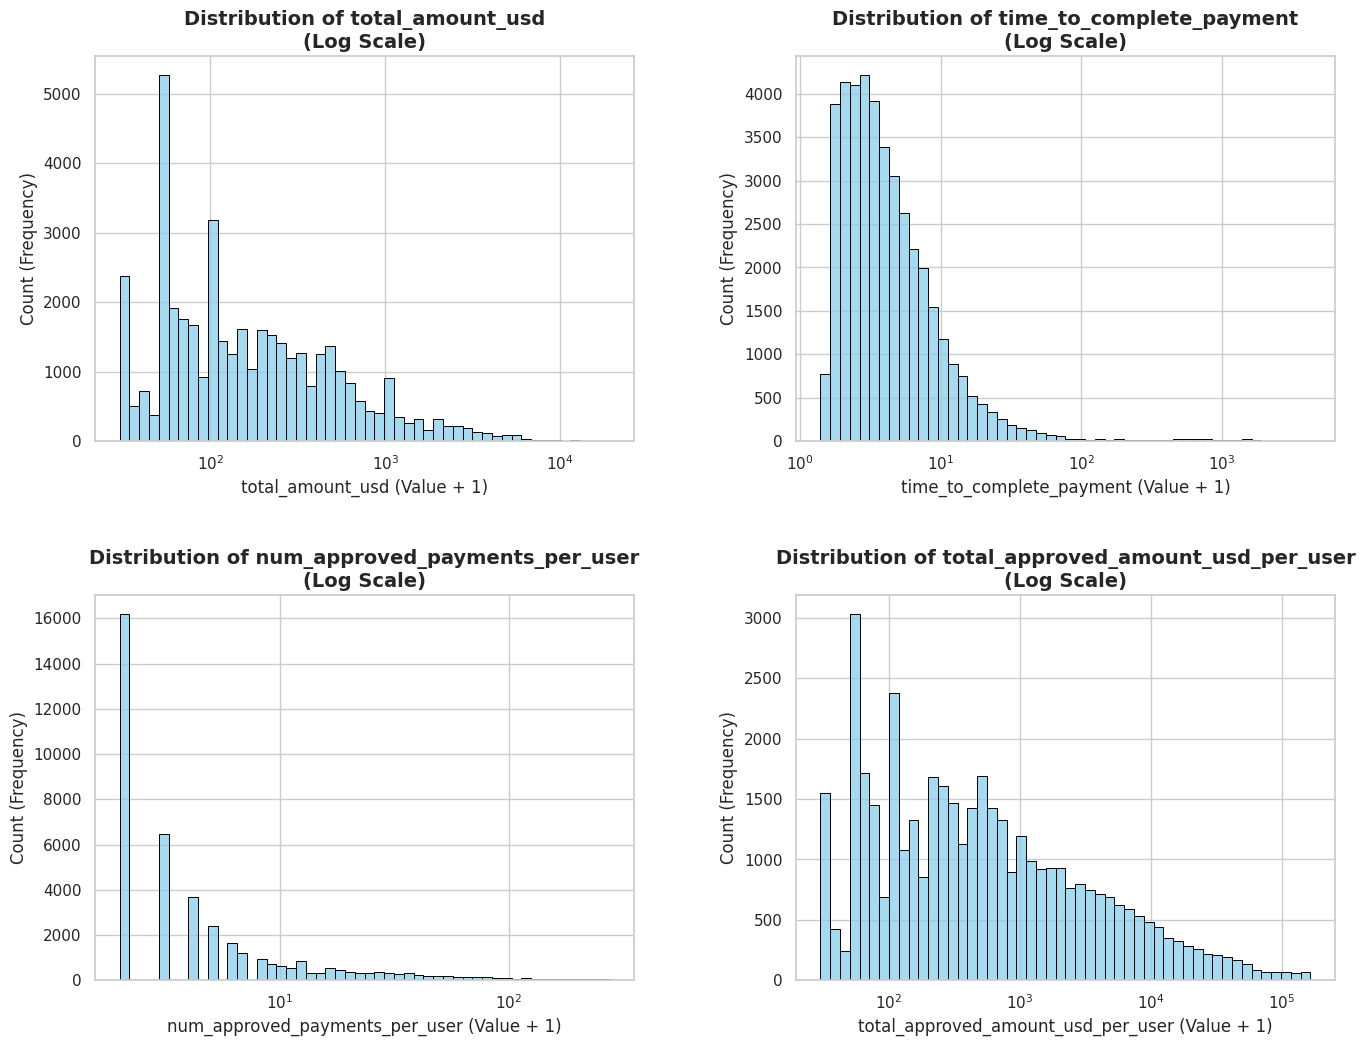

In [40]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

columns = [
    'total_amount_usd',
    'time_to_complete_payment',
    'num_approved_payments_per_user',
    'total_approved_amount_usd_per_user'
]

for i, col in enumerate(columns):
    ax = axes[i//2, i%2]

    sns.histplot(raw_data[col] + 1, bins=50, ax=ax, kde=False, log_scale=True, color='skyblue', edgecolor='black')

    ax.set_title(f'Distribution of {col}\n(Log Scale)', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{col} (Value + 1)', fontsize=12)
    ax.set_ylabel('Count (Frequency)', fontsize=12)

plt.show()

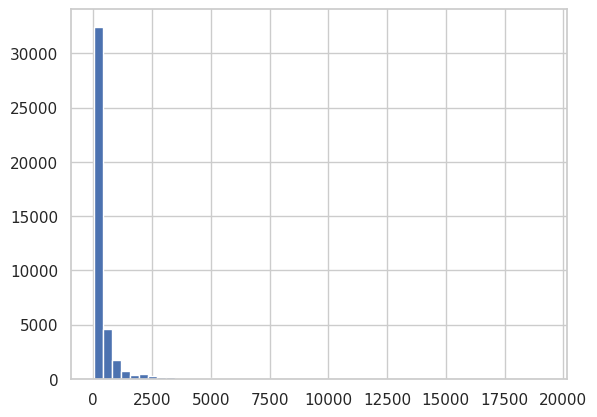

In [41]:
plt.hist(raw_data['total_amount_usd'], bins=50)
plt.show()

## Feature Engineering

Adding new features:
- Seniority: Payments occurring within the user's first few seconds (Seniority ≈ 0) carry a higher risk level.
- Time Since Last Payment: An extremely short interval (seconds) may indicate a "replay attack" or a bot attempting to process transactions rapidly.
- Average Time: If a user typically pays once a month and suddenly processes many transactions in a single day, it triggers a red flag (Anomaly).


In [42]:
raw_data['payment_timestamp'] = pd.to_datetime(raw_data['payment_timestamp'])
raw_data = raw_data.sort_values(['user_id', 'payment_timestamp'])

raw_data['seniority'] = (raw_data['payment_timestamp'] - raw_data['first_approved_payment_timestamp']).dt.days

raw_data['time_since_last_payment'] = raw_data.groupby('user_id')['payment_timestamp'].diff().dt.total_seconds() / 3600

raw_data['avg_time_between_payments'] = raw_data.groupby('user_id')['time_since_last_payment'].transform(lambda x: x.expanding().mean()) # User Based - not to be used for modelling

In [43]:
raw_data['time_since_last_payment'] = raw_data['time_since_last_payment'].fillna(999999)

In [44]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['prev_avg_amount'] = df_sorted.groupby('user_id')['total_amount_usd'].transform(lambda x: x.shift(1).expanding().mean())

df_sorted['amount_to_avg_ratio'] = (df_sorted['total_amount_usd'] / df_sorted['prev_avg_amount']).fillna(1)

In [45]:
raw_data['amount_to_avg_ratio'] = df_sorted['amount_to_avg_ratio']

In [46]:
print(df_sorted['amount_to_avg_ratio'].describe())

count    41321.000000
mean         1.396797
std          2.418013
min          0.010256
25%          0.993566
50%          1.000000
75%          1.199944
max        204.198826
Name: amount_to_avg_ratio, dtype: float64


I engineered the amount_to_avg_ratio feature to detect sudden shifts in purchasing behavior. The analysis revealed extreme outliers with ratios as high as 204x the user's historical average, involving transactions up to $12,000. These spikes are strong indicators of potential Account Takeover (ATO), where an established account is suddenly used for high-value fraudulent purchases that deviate significantly from previous activity


In [47]:
print(df_sorted[df_sorted['amount_to_avg_ratio'] > 1][['total_amount_usd', 'amount_to_avg_ratio']].sort_values('amount_to_avg_ratio', ascending=False).head(10))

       total_amount_usd  amount_to_avg_ratio
19067           8175.10           204.198826
17425           8910.16           138.614810
38862          12244.45           111.313182
25849          10000.00           100.000000
31234           6148.34            97.053512
9530            2763.80            72.312925
17702           5000.00            71.428571
5815            4000.00            66.666667
33305           5581.79            65.722242
19730           3110.73            61.562042


I identified a specific pattern where a user processed three identical transactions ($55.16) within a short timeframe, one of which was a 'broken record' with missing device data. To capture this, I engineered a Same-Amount Velocity feature. This ensures that rapid, identical-amount bursts—a common signature of automated bot attacks or credit card testing—are explicitly prioritized by the anomaly detection model.


In [48]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['is_same_as_prev_amount'] = (
    (df_sorted['total_amount_usd'] == df_sorted.groupby('user_id')['total_amount_usd'].shift(1))
).astype(int)

raw_data['is_same_as_prev_amount'] = df_sorted['is_same_as_prev_amount']

In [49]:
temp_series = df_sorted.set_index('payment_timestamp')

rolling_count = (
    temp_series.groupby(['user_id', 'total_amount_usd'])['total_amount_usd']
    .rolling('24h', closed='left')
    .count()
)

df_sorted['same_amount_count_24h'] = rolling_count.values
df_sorted['same_amount_count_24h'] = df_sorted['same_amount_count_24h'].fillna(0)

raw_data['same_amount_count_24h'] = df_sorted['same_amount_count_24h']

In [50]:
raw_data['same_amount_count_24h'].describe() # value of 1 is suspicous and need to be reviewed, values above 1 are anomalies

,same_amount_count_24h
count,41321.000000
mean,0.099901
std,0.559517
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,15.000000


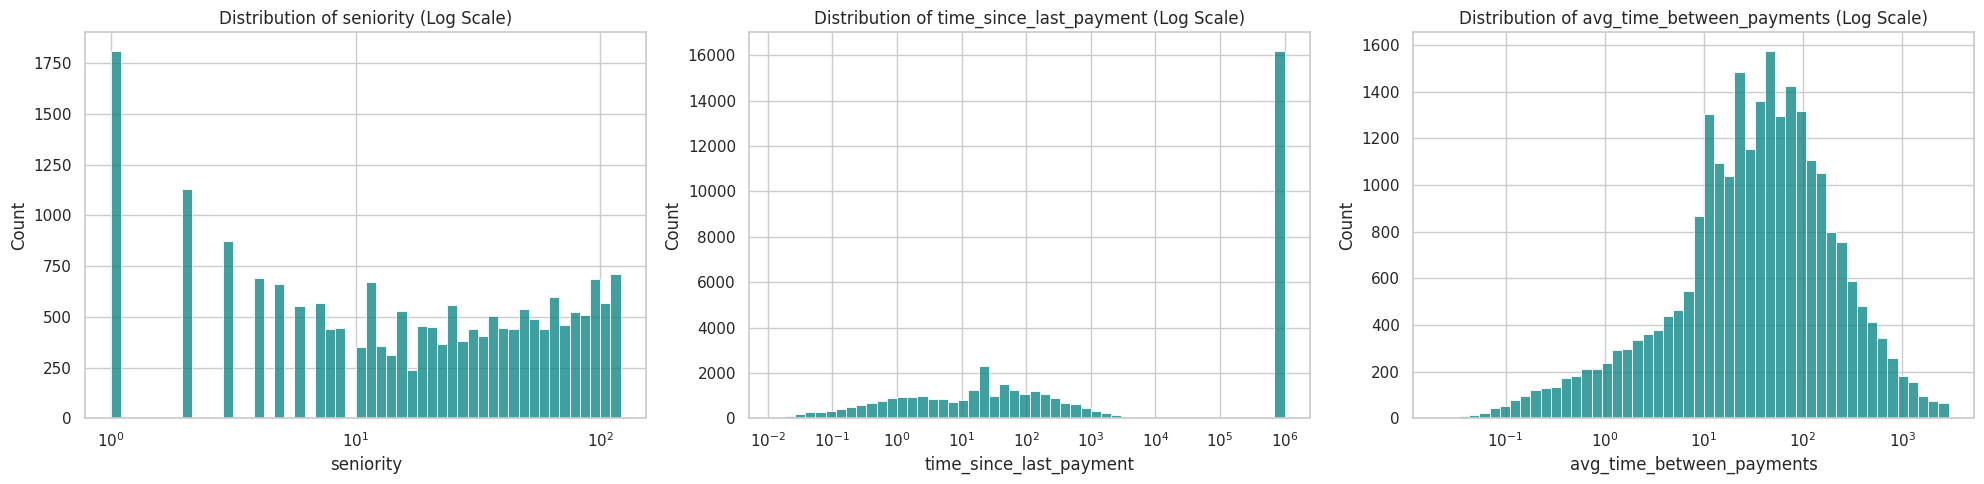

In [51]:
new_features = ['seniority', 'time_since_last_payment', 'avg_time_between_payments']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(new_features):
    plot_data = raw_data[raw_data[col] > 0][col]

    sns.histplot(plot_data, bins=50, ax=axes[i], log_scale=True, color='teal')
    axes[i].set_title(f'Distribution of {col} (Log Scale)')

plt.tight_layout()
plt.show()


In [52]:
raw_data['is_new_user'] = (raw_data.num_approved_payments_per_user ==  1)

## Categorical Features Analysis

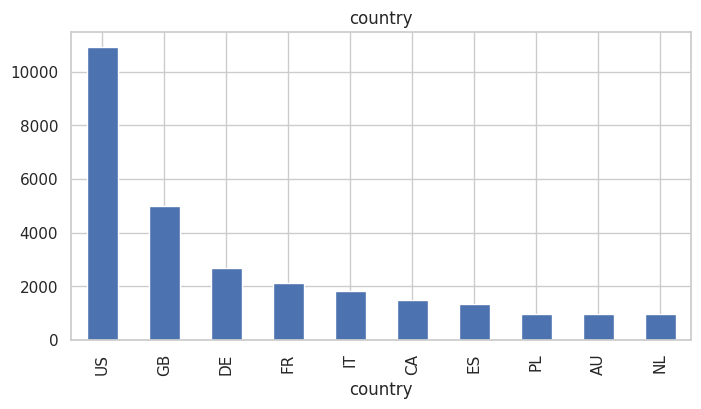

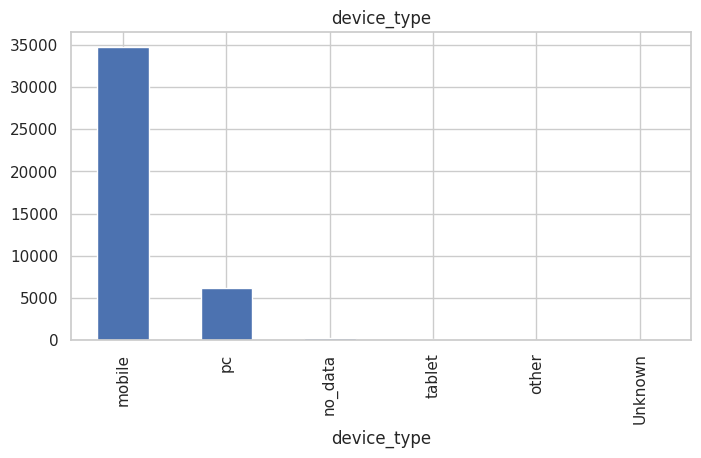

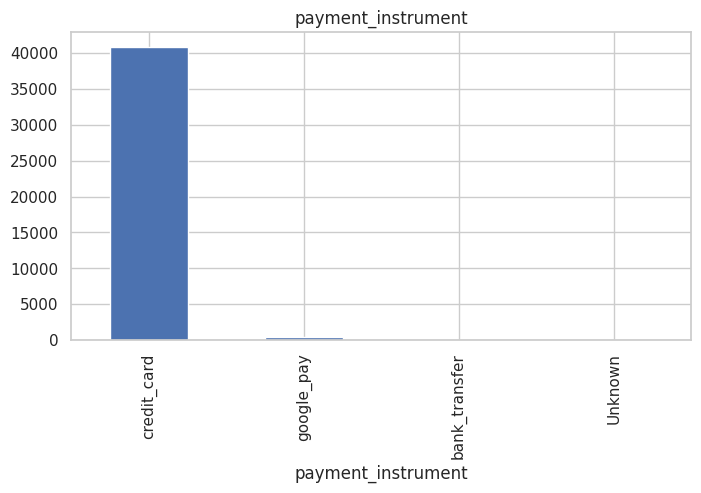

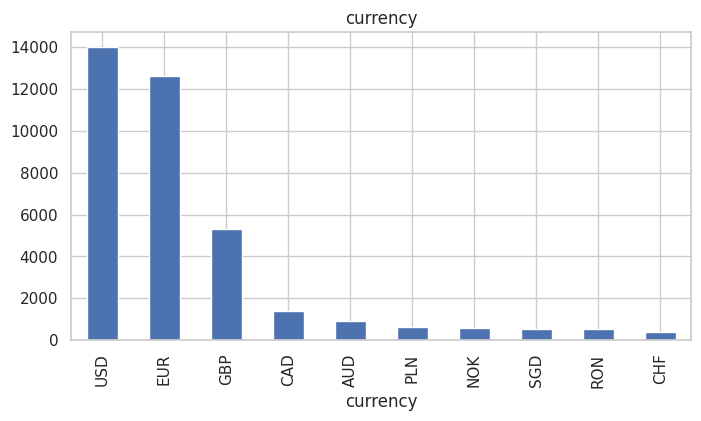

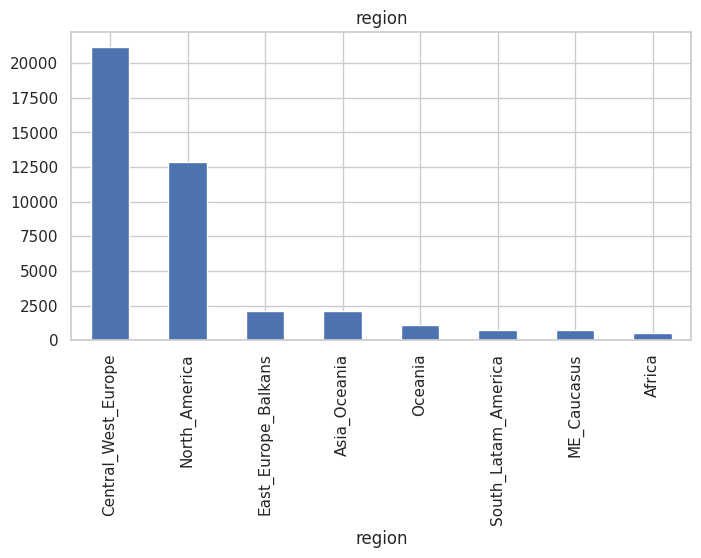

In [53]:
cat_cols = ['country', 'device_type', 'payment_instrument', 'currency', 'region']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    raw_data[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.show()

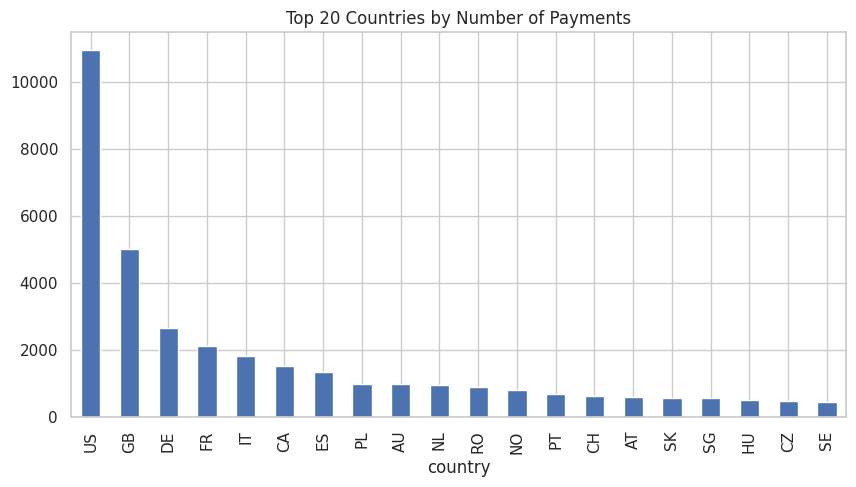

In [54]:
country_counts = raw_data['country'].value_counts()

plt.figure(figsize=(10,5))
country_counts.head(20).plot(kind='bar')
plt.title("Top 20 Countries by Number of Payments")
plt.show()

- Merchant - maybe some merchants have lower security
- check for high concentration of impossible travel transactions or broken records

In [55]:
merchant_risk = raw_data.groupby('merchant_id')['is_impossible_travel'].mean().sort_values(ascending=False)
print(merchant_risk.head(10))

merchant_id
238    0.003024
406    0.002188
602    0.000292
160    0.000259
288    0.000096
72     0.000000
88     0.000000
95     0.000000
75     0.000000
92     0.000000
Name: is_impossible_travel, dtype: float64


While is_impossible_travel occurs only across 5 merchants, I opted to include merchant_id via Frequency Encoding rather than creating a manual joint feature. This allows the model to naturally capture the interaction between specific merchants and geographic risks without over-fitting to current data

In [56]:
merchant_stats = raw_data.groupby('merchant_id')['total_amount_usd'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Card Testing?
small_amount_merchants = merchant_stats[merchant_stats['median'] < 2].sort_values('count', ascending=False)

#high volume
whale_merchants = merchant_stats[merchant_stats['median'] > 1000].sort_values('count', ascending=False)

print("Card Testing suspected:")
print(small_amount_merchants.head())


Card Testing suspected:
Empty DataFrame
Columns: [mean, median, std, min, max, count]
Index: []


In [57]:
broken_rows = raw_data[raw_data['device_type']=='Unknown']

broken_merchants = broken_rows['merchant_id'].value_counts()

print("distribution of merchants in broken records:")
print(broken_merchants)

if len(broken_merchants) == 1:
    print(f"All records root to the same merchant {broken_merchants.index[0]}")
else:
    print("Records spread across merchants")


distribution of merchants in broken records:
merchant_id
579    5
288    3
160    2
237    1
417    1
Name: count, dtype: int64
Records spread across merchants


## Time Based Analysis

In [58]:
raw_data['hour'] = raw_data['payment_timestamp'].dt.hour
raw_data['day'] = raw_data['payment_timestamp'].dt.date
raw_data['weekday'] = raw_data['payment_timestamp'].dt.weekday

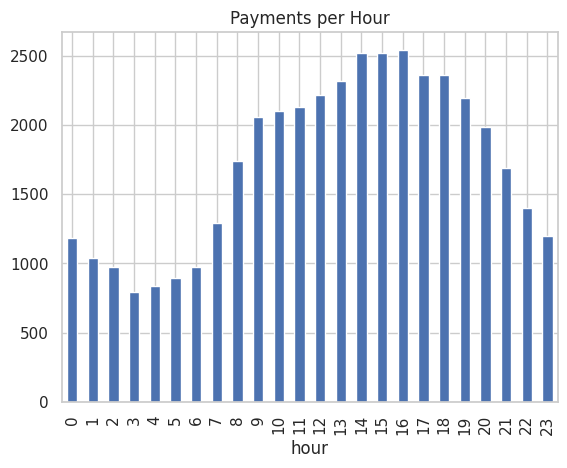

In [59]:
raw_data['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Payments per Hour")
plt.show()

most payments occur afternoon, 03:00 - 05:00 are the most "dead" hours

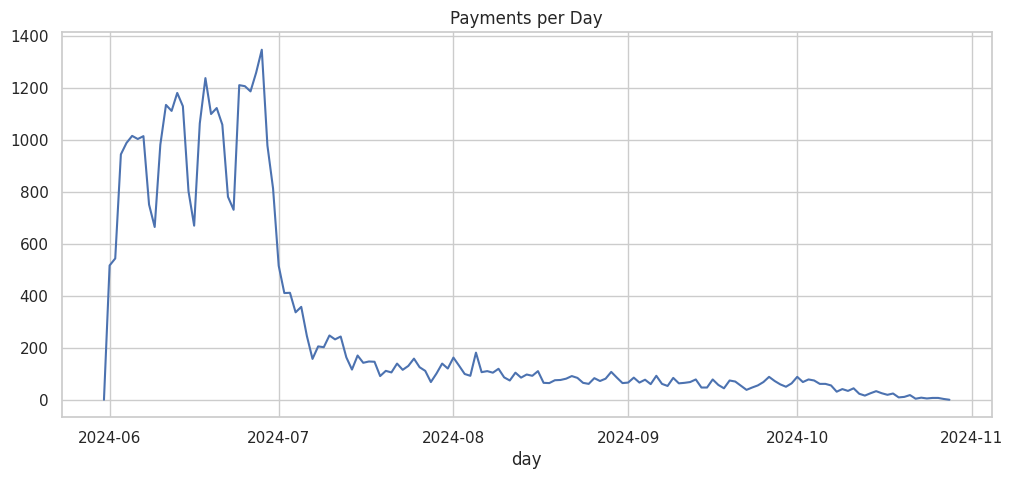

In [60]:
daily_counts = raw_data.groupby('day').size()

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Payments per Day")
plt.show()

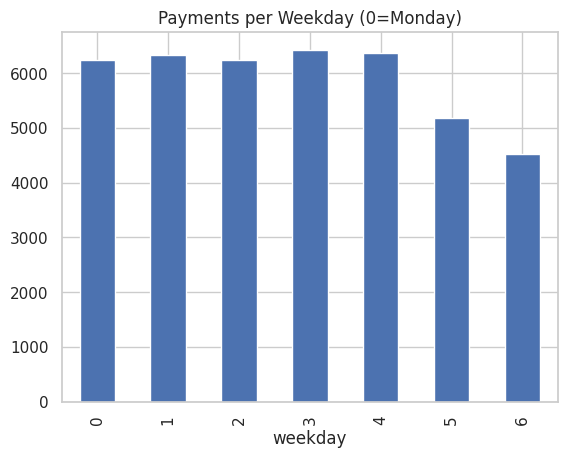

In [61]:
raw_data['weekday'].value_counts().sort_index().plot(kind='bar')
plt.title("Payments per Weekday (0=Monday)")
plt.show()

Most payments are during working weekdays and not weekends

## Drift Analysis

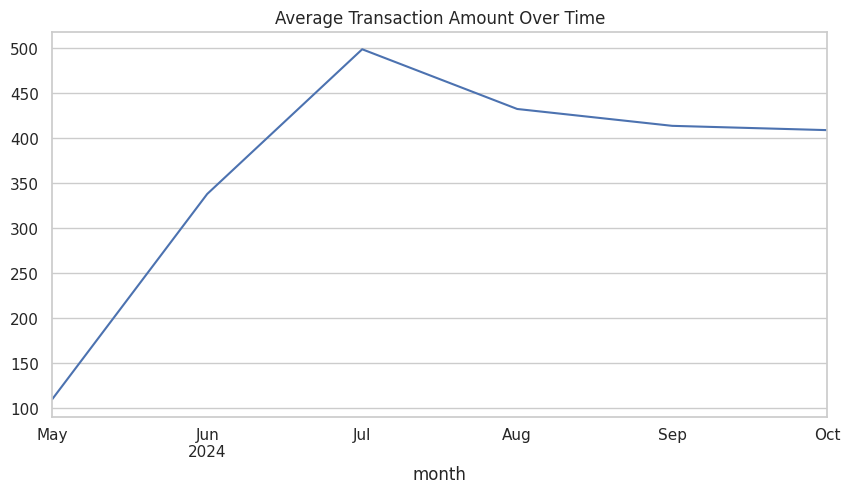

In [62]:
raw_data['month'] = raw_data['payment_timestamp'].dt.to_period('M')

monthly_amount = raw_data.groupby('month')['total_amount_usd'].mean()

monthly_amount.plot(figsize=(10,5))
plt.title("Average Transaction Amount Over Time")
plt.show()

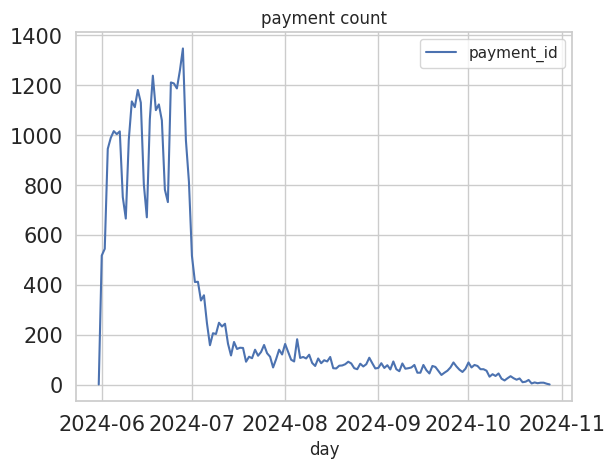

In [63]:
ts_count = raw_data.groupby(['day'])['payment_id'].count().reset_index().set_index('day')
ts_count.plot.line(title = "payment count",fontsize = 15)
plt.show()

- There is a decrease in daily payments over time while users probably become dormant

# Baseline Model: Isolation Forest

In [64]:
!pip install category_encoders

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import CountEncoder
from sklearn.ensemble import IsolationForest

In [66]:
cols_to_convert = ['merchant_id', 'geo_location', 'payment_instrument', 'device_type', 'currency']
for col in cols_to_convert:
    raw_data[col] = raw_data[col].astype('category')

In [67]:
raw_data['is_new_user'] = raw_data['is_new_user'].astype(int)

In [68]:
#  merchant_id, geo_location, payment_instrument, device_type, currency, hour will be encoded in pipeline

final_features = [
    'total_amount_usd',
    'amount_to_avg_ratio',
    'seniority',
    'time_since_last_payment',
    'time_to_complete_payment',
    'same_amount_count_24h',
    'is_same_as_prev_amount',
    'is_impossible_travel',
    'is_suspicious_velocity',
    'is_broken_record',
    'is_us_transaction',
    'is_new_user',
    'geo_location',
    'payment_instrument',
    'device_type',
    'currency',
    'merchant_id',
    'hour'
]

chronological split

In [69]:
raw_data = raw_data.sort_values('payment_timestamp')

train_size = int(len(raw_data) * 0.8)
train_df = raw_data.iloc[:train_size].copy()
test_df = raw_data.iloc[train_size:].copy()
print(f"Train dates: {train_df['payment_timestamp'].min()} to {train_df['payment_timestamp'].max()}")
print(f"Test dates: {test_df['payment_timestamp'].min()} to {test_df['payment_timestamp'].max()}")

Train dates: 2024-05-31 23:56:04 to 2024-07-12 17:36:22
Test dates: 2024-07-12 17:37:35 to 2024-10-28 11:47:18


In [70]:
X_train = train_df[final_features]
X_test = test_df[final_features]

missing_values = X_train.isna().sum()
print(missing_values[missing_values > 0])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Series([], dtype: int64)
X_train shape: (33056, 18)
X_test shape: (8265, 18)


In [71]:
missing_values = X_test.isna().sum()
print(missing_values[missing_values > 0])


Series([], dtype: int64)


In [72]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler

def sin_cos_encode(df):
    hours = df.values.flatten() if hasattr(df, 'values') else df.flatten()
    sin_hour = np.sin(2 * np.pi * hours / 24)
    cos_hour = np.cos(2 * np.pi * hours / 24)
    return np.column_stack([sin_hour, cos_hour])

def get_hour_names(transformer, input_features):
    return ["hour_sin", "hour_cos"]

cat_features = ['merchant_id', 'geo_location', 'payment_instrument', 'device_type', 'currency']
cyclical_feature = ['hour']
numeric_features = [f for f in final_features if f not in cat_features + cyclical_feature]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', CountEncoder(normalize=True, handle_unknown=0), cat_features),
        ('hour_cyc', FunctionTransformer(sin_cos_encode, feature_names_out=get_hour_names), cyclical_feature),
        ('num', 'passthrough', numeric_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(n_estimators=200, contamination=0.01, random_state=42))
])

pipeline.fit(X_train)

test_df['is_anomaly'] = pipeline.predict(X_test)
test_df['is_anomaly'] = test_df['is_anomaly'].map({1: 0, -1: 1})

print(f"Detected {test_df['is_anomaly'].sum()} anomalies in test set.")

Detected 844 anomalies in test set.


To validate the unsupervised results, I performed a dual validation approach:

Contextual Validation: Checked against pre-defined flags (Geographic anomalies and missing data).

Statistical Separation: Used PCA to visually confirm that the model isolates points in the sparse regions of the feature space.

In [73]:
anomalies = test_df[test_df['is_anomaly'] == 1]

broken_in_anomalies = anomalies['is_broken_record'].sum()
all_broken_test = test_df['is_broken_record'].sum()
print(f"Broken records caught: {broken_in_anomalies} out of {all_broken_test}")

same_amount_in_anomalies = anomalies[anomalies['same_amount_count_24h']>1].shape[0]
all_same_amount = test_df[test_df['same_amount_count_24h']>1].shape[0]
print(f"Same amount in 24h caught: {same_amount_in_anomalies} out of {all_same_amount}")

geo_in_anomalies = anomalies['is_impossible_travel'].sum()
print(f"Impossible Travel caught: {geo_in_anomalies}")

region_in_anomalies = anomalies['is_suspicious_velocity'].sum()
print(f"Suspicious Travel caught: {geo_in_anomalies}")

print("\nTop 5 High-Amount Anomalies:")
display(anomalies.sort_values('total_amount_usd', ascending=False)[['user_id', 'total_amount_usd', 'amount_to_avg_ratio', 'country', 'region']].head())

print("\nHigh Velocity (Same Amount) Anomalies:")
display(anomalies.sort_values('same_amount_count_24h', ascending=False)[['user_id', 'total_amount_usd', 'same_amount_count_24h', 'is_broken_record']].head())

Broken records caught: 1 out of 1
Same amount in 24h caught: 181 out of 263
Impossible Travel caught: 0
Suspicious Travel caught: 0

Top 5 High-Amount Anomalies:


,user_id,total_amount_usd,amount_to_avg_ratio,country,region
33666,11068046,15278.98,5.405857,GB,Central_West_Europe
33827,11068046,15276.75,2.873246,GB,Central_West_Europe
33874,11072890,13011.60,16.904329,GB,Central_West_Europe
38862,11080061,12244.45,111.313182,AE,Asia_Oceania
39159,11065893,12000.00,2.400000,US,North_America



High Velocity (Same Amount) Anomalies:


,user_id,total_amount_usd,same_amount_count_24h,is_broken_record
34453,11050510,500.0,11.0,0
34452,11050510,500.0,10.0,0
36656,11050510,500.0,10.0,0
36655,11050510,500.0,9.0,0
34350,11050510,400.0,9.0,0


In [74]:
analysis_cols = [
    'total_amount_usd', 'amount_to_avg_ratio', 'seniority',
    'time_since_last_payment', 'time_to_complete_payment',
    'same_amount_count_24h', 'is_impossible_travel', 'is_broken_record'
]

comparison = test_df.groupby('is_anomaly')[analysis_cols].mean().T
comparison['lift'] = comparison[1] / comparison[0]
print("--- Anomaly Feature Lift ---\nComparison Table (Mean Values)")
print(comparison.sort_values('lift', ascending=False))

--- Anomaly Feature Lift ---
Comparison Table (Mean Values)
is_anomaly                         0            1       lift
is_broken_record            0.000000     0.001185        inf
same_amount_count_24h       0.073710     0.975118  13.229167
time_to_complete_payment    3.066117    11.959322   3.900478
total_amount_usd          367.814913  1130.812678   3.074407
amount_to_avg_ratio         1.165817     2.161746   1.854277
seniority                  64.480528    63.405213   0.983323
time_since_last_payment   661.984332   339.872616   0.513415
is_impossible_travel        0.000404     0.000000   0.000000


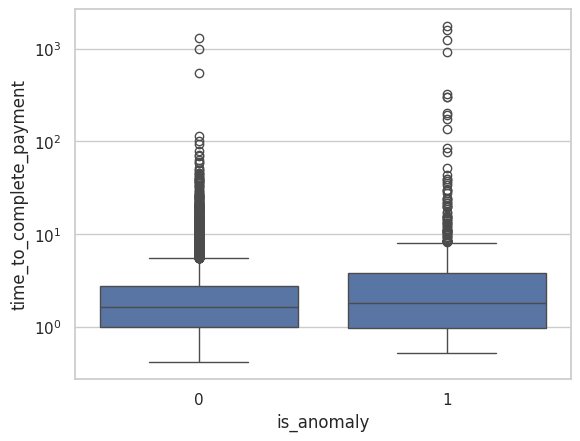

In [75]:
import seaborn as sns
sns.boxplot(x='is_anomaly', y='time_to_complete_payment', data=test_df)
plt.yscale('log')

**Primary Risk Drivers:**

The model identified Transaction Bursting (same_amount_count_24h) as the most significant anomaly indicator, with a 13x lift compared to normal traffic. Additionally, anomalies exhibited a significantly longer Time-to-Complete Payment (12s vs 3s), suggesting manual entry of stolen credentials or bot-latency

**High-Value Anomaly Detection:**

Detected anomalies averaged $1,128, nearly 3x the global average. The model successfully prioritized high-magnitude behavioral shifts, specifically catching records with missing metadata (is_broken_record).

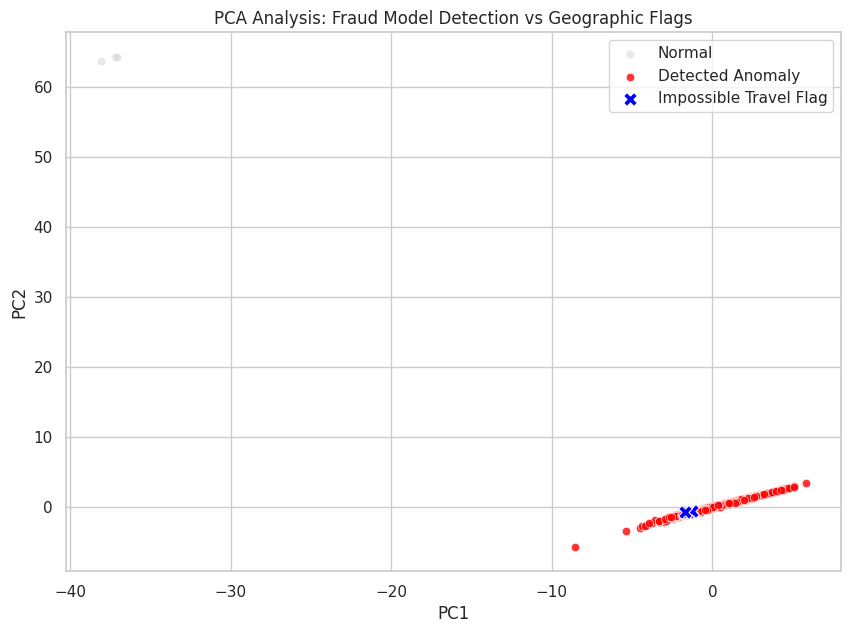

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

X_proc = pipeline.named_steps['preprocessor'].transform(test_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proc)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['is_anomaly'] = test_df['is_anomaly'].values
pca_df['is_impossible_travel'] = test_df['is_impossible_travel'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df[pca_df['is_anomaly'] == 0], x='PC1', y='PC2', color='lightgrey', alpha=0.5, label='Normal')
sns.scatterplot(data=pca_df[pca_df['is_anomaly'] == 1], x='PC1', y='PC2', color='red', alpha=0.8, label='Detected Anomaly')
sns.scatterplot(data=pca_df[pca_df['is_impossible_travel'] == 1], x='PC1', y='PC2', color='blue', marker='X', s=100, label='Impossible Travel Flag')

plt.title('PCA Analysis: Fraud Model Detection vs Geographic Flags')
plt.legend()
plt.show()


PCA Analysis:

Detection Logic: The PCA visualization confirms that the model is primarily driven by a specific set of high-magnitude features as seen by the distinct linear cluster of red points.
The 'Missed' Flags: The geographic flags (Blue X) are aligned with the detected anomalies but are positioned closer to the 'Normal' cluster. This indicates that while the model recognizes their anomalous direction, they were outranked by more extreme monetary outliers.

Future Improvements:

This visualization justifies the need for a Hybrid Risk Engine. I would recommend adding a 'Hard Rule' layer to automatically flag geographic impossibility, as it represents a logical risk that doesn't always correlate with statistical magnitude.

In [77]:
extreme_points = pca_df[pca_df['PC2'] > 60]
isolated_indices = extreme_points.index

display(test_df.iloc[isolated_indices][final_features])

,total_amount_usd,amount_to_avg_ratio,seniority,time_since_last_payment,time_to_complete_payment,same_amount_count_24h,is_same_as_prev_amount,is_impossible_travel,is_suspicious_velocity,is_broken_record,is_us_transaction,is_new_user,geo_location,payment_instrument,device_type,currency,merchant_id,hour
33541,102.83,1.0,17,999999.0,4.028184,0.0,0,0,0,0,0,1,BR,credit_card,mobile,BRL,265,20
34312,185.96,1.0,29,999999.0,4.629618,0.0,0,0,0,0,0,1,BR,credit_card,mobile,BRL,265,0
40463,107.80,1.0,101,999999.0,8.362652,0.0,0,0,0,0,0,1,BR,credit_card,pc,BRL,265,13


In [78]:
test_df[test_df['is_new_user']==1]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,...,avg_time_between_payments,amount_to_avg_ratio,is_same_as_prev_amount,same_amount_count_24h,is_new_user,hour,day,weekday,month,is_anomaly
33541,67619070,11086983,265,2024-07-15 20:52:22,2024-06-28 15:21:34,102.83,credit_card,BRL,4.028184,1,...,NaN,1.0,0,0.0,1,20,2024-07-15,0,2024-07,0
34312,67732092,11071139,265,2024-07-22 00:44:00,2024-06-22 20:41:16,185.96,credit_card,BRL,4.629618,1,...,NaN,1.0,0,0.0,1,0,2024-07-22,0,2024-07,0
40463,69184549,11067981,265,2024-10-01 13:47:01,2024-06-21 14:37:23,107.80,credit_card,BRL,8.362652,1,...,NaN,1.0,0,0.0,1,13,2024-10-01,1,2024-10,0


In [79]:
train_df['is_new_user'].sum()/train_df.shape[0]*100

np.float64(49.02287028073572)

In [80]:
3/test_df.shape[0]*100

0.03629764065335753

I identified a significant Data Drift between the training and testing sets: New Users dropped from 50% in Train to 0.04% in Test. This caused the PCA to isolate rare new users in the Test set as statistical anomalies (the Brazilian cluster). In a production scenario, this would indicate a need to retrain the model on more recent data to ensure the definition of 'Normal' remains current.


The observed shift in user seniority between Train and Test is not a data quality issue, but a reflection of the Cohort's lifecycle (users joined in June and were tracked for 4 months).


In [81]:
br_isolated = test_df.iloc[isolated_indices]
br_all = test_df[test_df['country'] == 'BR']

print("\n--- Isolated Brazil Points vs Brazil Average ---")
cols_to_show = ['total_amount_usd', 'amount_to_avg_ratio', 'merchant_id', 'payment_instrument']
print("Isolated:")
print(br_isolated[cols_to_show])
print("\nBrazil Mean Amount:", br_all['total_amount_usd'].mean())


--- Isolated Brazil Points vs Brazil Average ---
Isolated:
       total_amount_usd  amount_to_avg_ratio merchant_id payment_instrument
33541            102.83                  1.0         265        credit_card
34312            185.96                  1.0         265        credit_card
40463            107.80                  1.0         265        credit_card

Brazil Mean Amount: 515.7742307692307


**False Positive Mitigation:**

Diagnostic PCA identified isolated clusters (Brazilian transactions via Merchant 265). Detailed analysis confirmed these were low-value, stable transactions. The model correctly classified them as 'Normal,' demonstrating robustness against geographic noise

**False Negatives Analysis**

In [82]:
test_df['anomaly_score'] = pipeline.named_steps['model'].decision_function(X_proc)

test_df['anomaly_percentile'] = test_df['anomaly_score'].rank(pct=True) * 100

imp_travel_cases = test_df[test_df['is_impossible_travel'] == 1]
print("--- Impossible Travel Percentiles ---")
print(imp_travel_cases['anomaly_percentile'].describe())

broken_cases = test_df[test_df['is_broken_record'] == 1]
print("\n--- Broken Records Percentiles ---")
print(broken_cases['anomaly_percentile'].describe())


--- Impossible Travel Percentiles ---
count     3.000000
mean     65.484977
std      15.354476
min      49.183303
25%      58.390805
50%      67.598306
75%      73.635814
max      79.673321
Name: anomaly_percentile, dtype: float64

--- Broken Records Percentiles ---
count    1.00000
mean     1.23412
std          NaN
min      1.23412
25%      1.23412
50%      1.23412
75%      1.23412
max      1.23412
Name: anomaly_percentile, dtype: float64


Although the geographic features were correctly engineered, the Isolation Forest assigned them a low anomaly rank (mean percentile of 65 means these transactions were scored as more normal than 65% of transactions). This is because the model is naturally biased toward continuous high-magnitude features (like transaction amount) rather than binary flags. This finding validates the industry standard of using Hybrid Systems: where ML handles complex patterns, and Deterministic Rules handle high-confidence indicators like geographic impossibility.


## Investigate cases

### The most anomalous result

In [ ]:
import shap

X_proc = pipeline.named_steps['preprocessor'].transform(test_df[final_features])

explainer = shap.Explainer(pipeline.named_steps['model'], X_proc)
shap_values = explainer(X_proc)

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

shap_values.feature_names = list(feature_names)

 20%|====                | 1693/8265 [00:45<02:54]       

In [ ]:
most_anomalous_idx = test_df['anomaly_score'].idxmin()

row_pos_extreme = test_df.index.get_loc(most_anomalous_idx)

print(f"Explaining most anomalous transaction (Index: {most_anomalous_idx})")
shap.plots.waterfall(shap_values[row_pos_extreme])

Analysis of the most anomalous transaction reveals that the model's decision was primarily driven by a high amount_to_avg_ratio (10.3x) combined with a large transaction volume of $2,969. Furthermore, the model identified technical anomalies: a rare device_type frequency (0.149) and an unusually long payment completion time (76 seconds). These factors together allowed the Isolation Forest to isolate this record significantly faster than the rest of the population score of 6.057 vs mean score of 9.342

### Normal-looking transaction that the model flaged as suspicous

In [ ]:
test_df[test_df['payment_id']==67588445][final_features]

In [ ]:
target_index = 33303

row_pos = test_df.index.get_loc(target_index)

In [ ]:
shap.plots.waterfall(shap_values[row_pos])

This case demonstrates the model's ability to detect contextual anomalies. While the transaction amount is low and seemingly safe ($57.88), the model flagged it due to a combination of technical outliers: a rare device type (freq 0.149) and a specific temporal pattern (time_since_last_payment and hour_sin). This shows that the Isolation Forest effectively monitors account integrity, not just high-dollar theft.

### Suspicous transaction that the model did not catch (Impossible travel)

In [ ]:
test_df[test_df.index==33575][final_features]

In [ ]:
target_index = 33575

row_pos = test_df.index.get_loc(target_index)

shap.plots.waterfall(shap_values[row_pos])

Analysis of False Negatives (Impossible Travel):

By analyzing the SHAP values for one of the 3 missed 'Impossible Travel' cases, we can see that the model did recognize the geographic risk (negative contribution of 0.15). However, this signal was completely overwhelmed by 'Safe Signals': the transaction amount was low ($67), and more importantly, the device type was highly common (84% frequency).
In the eyes of the Isolation Forest, a standard device performing a small transaction looks so 'normal' that it overrides the geographic impossibility. This proves that ML is not a silver bullet and must be combined with Hard Rules for high-confidence flags like geographic jumps.

In [ ]:
results_n = {}
n_list = [50, 100, 200, 500]

for n in n_list:
    pipeline.set_params(model__n_estimators=n)
    pipeline.fit(train_df[final_features])
    preds = pipeline.predict(test_df[final_features])
    results_n[n] = (preds == -1).sum()

print("\n--- Stability check: n_estimators ---")
print(results_n)



The model is stable around 200 estimators

## Contamination Stability

In [ ]:
contams = [0.005, 0.01, 0.02, 0.03]
stability_df = pd.DataFrame(index=test_df.index)

for c in contams:
    pipeline.set_params(model__contamination=c)
    pipeline.fit(train_df[final_features])
    preds = pipeline.predict(test_df[final_features])
    stability_df[f'anomaly_{c}'] = (preds == -1).astype(int)

print("\n--- Stability Correlation (Contamination) ---")
print(stability_df.corr())

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(stability_df.corr(), annot=True, cmap='Greens')
plt.title('Stability of Anomalies across Contamination Levels')
plt.show()


**Model Stability:**
Sensitivity analysis confirmed high stability. A 0.74 correlation between  contamination levels 0.005 and 0.01 shows that the most severe anomalies are consistently identified, regardless of the threshold.

In [ ]:
overlap = stability_df.all(axis=1).sum()
print(f"number of anomalies in all contamination levels: {overlap}")

stability_df.sum().plot(kind='bar', color='skyblue')
plt.title('Anomaly Count per Contamination Level')
plt.ylabel('Number of Anomalies')
plt.show()

# Adding LOF

Local Outlier Factor (LOF) detects local density anomalies

For the LOF model, I utilized the industry-standard n_neighbors=20. This value provides a robust balance, allowing the model to detect localized density deviations (such as a rare country-merchant combination) without being overly sensitive to individual transactional noise. While further hyperparameter tuning via grid search on neighbors could refine the local sensitivity, the current configuration successfully complemented the Isolation Forest by identifying 75 unique contextual anomalies.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

X_train_proc = pipeline.named_steps['preprocessor'].transform(train_df)
X_test_proc = pipeline.named_steps['preprocessor'].transform(test_df)

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_proc)
X_scaled_test = scaler.transform(X_test_proc)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=True)
lof.fit(X_scaled_train)
test_df['lof_anomaly'] = lof.predict(X_scaled_test)
test_df['lof_anomaly'] = test_df['lof_anomaly'].map({1: 0, -1: 1})

lof_geo_hits = test_df[(test_df['is_impossible_travel'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_geo_hits)} out of 3 Impossible Travel cases.")

In [ ]:
lof_state_travel_hits = test_df[(test_df['is_suspicious_velocity'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_state_travel_hits)} out of 3 Suspicous Travel cases.")

lof_broken_hits = test_df[(test_df['is_broken_record'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_broken_hits)} out of {all_broken_test} Broken records cases.")

lof_velocity_hits = test_df[(test_df['same_amount_count_24h'] > 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_velocity_hits)} out of {all_same_amount} Same amount in 24h cases.")

Decision Hirerchy

I utilized the raw decision scores from both models instead of binary labels to create a continuous Risk Spectrum. This approach allows for nuanced decision-making, such as differentiating between 'High Risk' for immediate blocking and 'Medium Risk' for manual review. Furthermore, it enables a more sophisticated Ensemble Integration, where the combined probability from different models provides a more robust indicator than a simple voting mechanism.


In [ ]:
# --- Deterministic Rules ---
test_df['hard_flag'] = (
    (test_df['is_impossible_travel'] == 1) |
    (test_df['is_suspicious_velocity'] == 1) |
    (test_df['same_amount_count_24h'] >= 1) |
    (test_df['is_broken_record'] == 1)
).astype(int)

# --- ML Ensemble Score ---
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

if_scores = pipeline.named_steps['model'].decision_function(X_test_proc)
lof_scores_test = lof.decision_function(X_test_proc)

if_risk = 1 - scaler.fit_transform(if_scores.reshape(-1, 1)).flatten()
lof_risk = 1 - scaler.fit_transform(lof_scores_test.reshape(-1, 1)).flatten()

test_df['ml_risk_score'] = (0.7 * if_risk) + (0.3 * lof_risk)

In [ ]:
high_risk_threshold = test_df['ml_risk_score'].quantile(0.99)
med_risk_threshold = test_df['ml_risk_score'].quantile(0.90)

def final_decision_calibrated(row):
    if row['hard_flag'] == 1:
        return 'Critical - Rule Triggered'
    elif row['ml_risk_score'] >= high_risk_threshold:
        return 'High Risk - ML Detected'
    elif row['ml_risk_score'] >= med_risk_threshold:
        return 'Medium Risk - Review'
    else:
        return 'Low Risk - Approve'

test_df['final_action'] = test_df.apply(final_decision_calibrated, axis=1)

print(test_df['final_action'].value_counts().sort_index())

In [ ]:
test_df['if_risk'] = if_risk
test_df['lof_risk'] = lof_risk

# Correlation
correlation = test_df['if_risk'].corr(test_df['lof_risk'])
print(f"Correlation between IF and LOF risk scores: {correlation:.4f}")

# Unique anomalies for LOF
if_threshold = test_df['if_risk'].quantile(0.99)
lof_threshold = test_df['lof_risk'].quantile(0.99)

lof_only = test_df[
    (test_df['lof_risk'] >= lof_threshold) &
    (test_df['if_risk'] < if_threshold) &
    (test_df['hard_flag'] == 0)
]

print(f"Number of unique anomalies caught ONLY by LOF: {len(lof_only)}")

if len(lof_only) > 0:
    display(lof_only[['total_amount_usd', 'country', 'geo_location', 'merchant_id']].head())

Complementary Model Strategy (Ensemble Analysis):

My analysis revealed a near-zero correlation (-0.0030) between Isolation Forest and LOF risk scores. This indicates that the two models identify fundamentally different types of fraud.
Isolation Forest excels at detecting global behavioral outliers (extreme amounts and velocity bursts).
LOF successfully captured an additional 75 unique anomalies (e.g., high-value transactions in specific regions like CY, SG, and CH) that were missed by the global model.
By integrating both, the system provides a dual-lens detection engine that is sensitive to both global spikes and local contextual deviations, significantly reducing the 'blind spots' of the fraud detection pipeline.

**Future Production Architecture (Retraining Strategy):**

The observed shift in user seniority between Train and Test is not a data quality issue, but a reflection of the Cohort's lifecycle (users joined in June and were tracked for 4 months).
While the current model effectively captures anomalies for this specific group as they mature, in a production environment, we would implement Continuous Retraining. This ensures the model maintains a balanced representation of both 'New' and 'Established' users, preventing it from flagging legitimate new sign-ups as anomalies simply because they became statistically rare during the later stages of this specific cohort.

Future Steps

In the future, I would consider adding a One-Class SVM layer to detect more nuanced, non-linear anomalies. While my current ensemble (IF + LOF + Rules) is highly effective at catching 'magnitude' and 'density' outliers, OCSVM could help identify structural anomalies where individual features appear normal, but their specific interaction falls outside the learned decision boundary. However, due to its computational cost and sensitivity to noise, I prioritized the current robust architecture for this stage

To demonstrate real-time applicability, I implemented a Streamlit-based simulator that processes transactions sequentially, maintains a dynamic transaction history, and computes risk scores on-the-fly, mimicking a production fraud detection pipeline